In [3]:
!unzip "/content/drive/MyDrive/ResNet/food data.zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/food data/train/kadai_paneer/337.jpg  
  inflating: /content/food data/train/kadai_paneer/338.jpg  
   creating: /content/food data/train/Kulfi/
  inflating: /content/food data/train/Kulfi/001.jpg  
  inflating: /content/food data/train/Kulfi/002.jpg  
  inflating: /content/food data/train/Kulfi/003.jpg  
  inflating: /content/food data/train/Kulfi/004.jpg  
  inflating: /content/food data/train/Kulfi/005.jpg  
  inflating: /content/food data/train/Kulfi/006.jpg  
  inflating: /content/food data/train/Kulfi/007.cms  
  inflating: /content/food data/train/Kulfi/007.jpg  
  inflating: /content/food data/train/Kulfi/008.jpg  
  inflating: /content/food data/train/Kulfi/009.jpg  
  inflating: /content/food data/train/Kulfi/010.jpg  
  inflating: /content/food data/train/Kulfi/011.jpg  
  inflating: /content/food data/train/Kulfi/012.jpg  
  inflating: /content/food data/train/Kulfi/013.jpg  
  inflating: /content/food

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

In [5]:
os.listdir("/content/food data")

['valid', 'test', 'train']

In [6]:
os.listdir("/content/food data/train")

['dhokla',
 'burger',
 'Crispy Chicken',
 'dal_makhani',
 'chole_bhature',
 'Taco',
 'paani_puri',
 'pav_bhaji',
 'Fries',
 'omelette',
 'Baked Potato',
 'Hot Dog',
 'fried_rice',
 'chapati',
 'idli',
 'Kulfi',
 'pizza',
 'cheesecake',
 'jalebi',
 'kadai_paneer',
 'apple_pie',
 'ice_cream',
 'chai',
 'momos',
 'Donut',
 'Pakode',
 'Sandwich',
 'sushi',
 'chicken_curry',
 'Taquito',
 'butter_naan',
 'kaathi_rolls',
 'Masala dosa',
 'samosa']

In [7]:
os.listdir("/content/food data/valid")

['dhokla',
 'kulfi',
 'burger',
 'pakode',
 'Crispy Chicken',
 'dal_makhani',
 'chole_bhature',
 'Taco',
 'paani_puri',
 'pav_bhaji',
 'Fries',
 'omelette',
 'Baked Potato',
 'Hot Dog',
 'fried_rice',
 'chapati',
 'idli',
 'pizza',
 'cheesecake',
 'jalebi',
 'kadai_paneer',
 'apple_pie',
 'ice_cream',
 'masala_dosa',
 'chai',
 'momos',
 'Donut',
 'Sandwich',
 'sushi',
 'chicken_curry',
 'Taquito',
 'butter_naan',
 'kaathi_rolls',
 'samosa']

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
train_data_path = "/content/food data/train"
valid_data_path = "/content/food data/valid"

In [10]:
import warnings
warnings.filterwarnings("ignore")

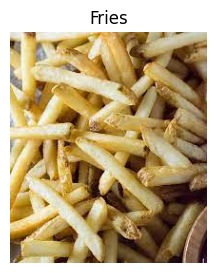

In [11]:
plt.figure(figsize=(5,3))
plt.title("Fries")

f = plt.imread(train_data_path + "/Fries/Fries-Train (692).jpeg")

plt.imshow(f)
plt.axis("off")
plt.show()

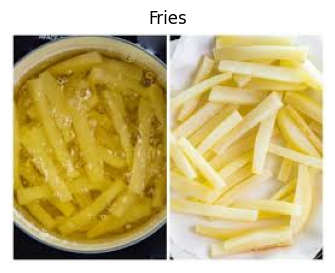

In [12]:
plt.figure(figsize=(5,3))
plt.title("Fries")

f = plt.imread(train_data_path + "/Fries/Fries-Train (778).jpeg")

plt.imshow(f)
plt.axis("off")
plt.show()

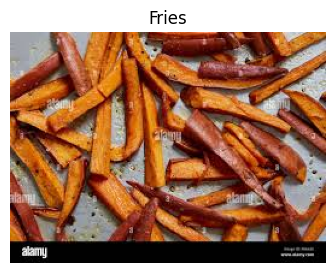

In [13]:
plt.figure(figsize=(5,3))
plt.title("Fries")

f = plt.imread(train_data_path + "/Fries/Fries-Train (8).jpeg")

plt.imshow(f)
plt.axis("off")
plt.show()

In [14]:
label_names = ['kulfi',
 'Baked Potato',
 'chapati',
 'chicken_curry',
 'Taco',
 'burger',
 'momos',
 'Donut',
 'pakode',
 'butter_naan',
 'Fries',
 'dal_makhani',
 'jalebi',
 'chole_bhature',
 'pav_bhaji',
 'pizza',
 'samosa',
 'kaathi_rolls',
 'fried_rice',
 'ice_cream',
 'dhokla',
 'Crispy Chicken',
 'Sandwich',
 'chai',
 'masala_dosa',
 'sushi',
 'idli',
 'apple_pie',
 'kadai_paneer',
 'Hot Dog',
 'cheesecake',
 'Taquito',
 'omelette',
 'paani_puri']

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
# To Train the ResNet well we are going to use Data Augumentation

train_data_rules = ImageDataGenerator(rescale = 1 / 255.0 ,
                                      rotation_range = 0.2 ,
                                      shear_range=0.2 ,
                                      horizontal_flip = True)

val_data_rules = ImageDataGenerator(rescale = 1 / 255.0 ,
                                      rotation_range = 0.2 ,
                                      shear_range=0.2 ,
                                      horizontal_flip = True)

In [19]:
final_train_data = train_data_rules.flow_from_directory(train_data_path , target_size=(256,256) ,
                                     color_mode='rgb',
                                     classes=label_names , class_mode='categorical')

final_val_data = val_data_rules.flow_from_directory(valid_data_path , target_size=(256,256) ,
                                     color_mode='rgb',
                                     classes=label_names , class_mode='categorical')



Found 7750 images belonging to 34 classes.
Found 1700 images belonging to 34 classes.


**Multilabel ResNet Architecure**

In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.activations import sigmoid,relu,softmax


ResNet50_model = ResNet50(input_shape=[256,256,3], weights='imagenet' , include_top=False)

for i in ResNet50_model.layers:
  i.trainable = False

inputs_to_ann = Flatten()(ResNet50_model.output)

# give Flatten values to ANN
h1_out = Dense(units=128,kernel_initializer='he_uniform',activation='relu')(inputs_to_ann)
h2_out = Dense(units=64,kernel_initializer='he_uniform',activation='relu')(h1_out)
h3_out = Dense(units=32,kernel_initializer='he_uniform',activation='relu')(h2_out)
output = Dense(units=34,kernel_initializer='glorot_uniform',activation='softmax')(h3_out)

model = Model(inputs = ResNet50_model.input , outputs = output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,376,514 (154.02 MB)

 Trainable params: 16,788,802 (64.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [22]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['Accuracy'])

In [23]:
final_train_data.classes

array([ 1,  1,  1, ..., 33, 33, 33], dtype=int32)

In [24]:
final_train_data.class_indices

{'kulfi': 0,
 'Baked Potato': 1,
 'chapati': 2,
 'chicken_curry': 3,
 'Taco': 4,
 'burger': 5,
 'momos': 6,
 'Donut': 7,
 'pakode': 8,
 'butter_naan': 9,
 'Fries': 10,
 'dal_makhani': 11,
 'jalebi': 12,
 'chole_bhature': 13,
 'pav_bhaji': 14,
 'pizza': 15,
 'samosa': 16,
 'kaathi_rolls': 17,
 'fried_rice': 18,
 'ice_cream': 19,
 'dhokla': 20,
 'Crispy Chicken': 21,
 'Sandwich': 22,
 'chai': 23,
 'masala_dosa': 24,
 'sushi': 25,
 'idli': 26,
 'apple_pie': 27,
 'kadai_paneer': 28,
 'Hot Dog': 29,
 'cheesecake': 30,
 'Taquito': 31,
 'omelette': 32,
 'paani_puri': 33}

In [ ]:
model.fit(final_train_data , validation_data=final_val_data , batch_size = 32 , epochs=25)

Epoch 1/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 243s 938ms/step - Accuracy: 0.0329 - loss: 3.8645 - val_Accuracy: 0.0288 - val_loss: 3.5371
Epoch 2/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 208s 858ms/step - Accuracy: 0.0317 - loss: 3.5011 - val_Accuracy: 0.0294 - val_loss: 3.5353
Epoch 3/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 209s 861ms/step - Accuracy: 0.0312 - loss: 3.4860 - val_Accuracy: 0.0294 - val_loss: 3.5434
Epoch 4/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 208s 852ms/step - Accuracy: 0.0314 - loss: 3.4767 - val_Accuracy: 0.0294 - val_loss: 3.5522
Epoch 5/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 213s 878ms/step - Accuracy: 0.0311 - loss: 3.4697 - val_Accuracy: 0.0294 - val_loss: 3.5618
Epoch 6/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 209s 859ms/step - Accuracy: 0.0295 - loss: 3.4660 - val_Accuracy: 0.0294 - val_loss: 3.5715
Epoch 7/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 213s 876ms/step - Accuracy: 0.0280 - loss: 3.4599 - val_Accuracy: 0.0294 - val_loss: 3.5812
Epoch 8/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 206s 848ms/step - Accuracy: 0.0267 -

In [25]:
model.save_weights("resnet.weights.h5")

**Take unseen data and give to trained Model and the Inference**

In [26]:
import cv2

In [27]:
def testing_function(image_path):
  t_image = cv2.imread(image_path,1)
  print(f"Original_image size : {t_image.shape}")
  resized_image = cv2.resize(t_image , (256,256))
  print(f"Resized Image size : {resized_image.shape}")
  scaled_down_image = resized_image / 255.0
  print(f"After Scaling : {scaled_down_image.shape}")
  added_dim_image = np.expand_dims(scaled_down_image , axis=0)
  print(f"After Adding 1 Dim size : {added_dim_image.shape}")
  print(label_names[np.argmax(model.predict(added_dim_image))])

  plt.imshow(t_image[: , : ,::-1])
  plt.show()

Original_image size : (159, 318, 3)
Resized Image size : (256, 256, 3)
After Scaling : (256, 256, 3)
After Adding 1 Dim size : (1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
paani_puri


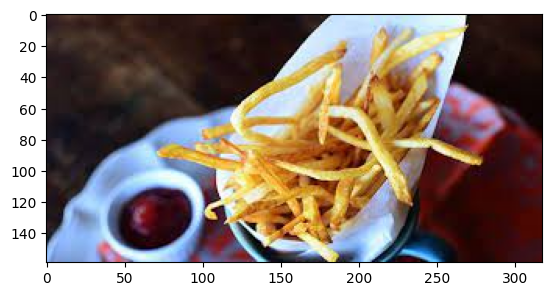

In [28]:
testing_function("/content/food data/test/Fries/Fries-Train (955).jpeg")

Original_image size : (251, 201, 3)
Resized Image size : (256, 256, 3)
After Scaling : (256, 256, 3)
After Adding 1 Dim size : (1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
chole_bhature


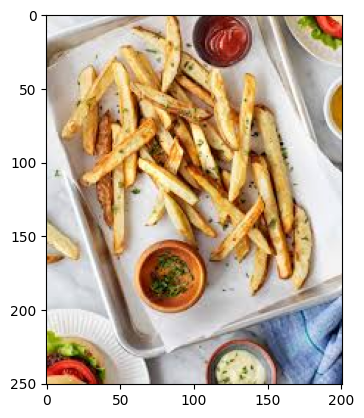

In [29]:
testing_function("/content/food data/test/Fries/Fries-Train (972).jpeg")

Original_image size : (532, 778, 3)
Resized Image size : (256, 256, 3)
After Scaling : (256, 256, 3)
After Adding 1 Dim size : (1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
chicken_curry


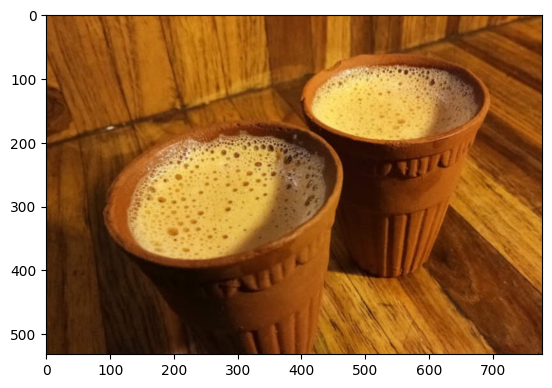

In [30]:
testing_function("/content/food data/test/chai/361.jpg")

In [31]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,376,514 (154.02 MB)

 Trainable params: 16,788,802 (64.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [32]:
y_true = final_val_data.classes

In [33]:
y_pred_prob = model.predict(final_val_data)
y_pred = np.argmax(y_pred_prob, axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 749ms/step


In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

In [35]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.024705882352941175
Precision: 0.03127335701242197
Recall   : 0.024705882352941175
F1 Score : 0.0045309345184537


In [36]:
class_names = list(final_val_data.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                precision    recall  f1-score   support

         kulfi       0.00      0.00      0.00        50
  Baked Potato       0.00      0.00      0.00        50
       chapati       0.00      0.00      0.00        50
 chicken_curry       0.03      0.56      0.06        50
          Taco       0.00      0.00      0.00        50
        burger       0.00      0.00      0.00        50
         momos       0.00      0.00      0.00        50
         Donut       0.00      0.00      0.00        50
        pakode       0.00      0.00      0.00        50
   butter_naan       0.00      0.00      0.00        50
         Fries       0.00      0.00      0.00        50
   dal_makhani       0.00      0.00      0.00        50
        jalebi       0.00      0.00      0.00        50
 chole_bhature       0.02      0.20      0.04        50
     pav_bhaji       0.00      0.00      0.00        50
         pizza       0.00      0.00      0.00        50
        samosa       0.00      0.00      0.00  

In [37]:
from sklearn.metrics import classification_report
import json

# Create classification report as dictionary
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Save as JSON
with open("classification_report_ResNet.json", "w") as f:
    json.dump(report, f, indent=4)

print("Classification report saved successfully!")

Classification report saved successfully!


In [38]:
model.save("resnet.keras")